# ============================================================
# 💁🏻 WALMART SALES ETL PIPELINE 🏪
### Description: Investigates the relationship between promotions, holidays and sales across stores
# ============================================================


## 0. IMPORTS AND CONFIGURATION

In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import warnings
# Suppress all warnings
warnings.filterwarnings("ignore")
import os

#Set the output location for the project 
output_path = "/Users/sarahnguyen313/Documents/Walmart Project"
import logging 


### File paths
Sales_File = 'train.csv'
Stores_File = 'stores.csv'
Features_File = 'features.csv'

Markdown_Cols= [
    'MarkDown1', 'MarkDown2', 'MarkDown3', 
    'MarkDown4', 'MarkDown5'
]

pd.options.display.float_format = '{:.2f}'.format

#Set a customised style for all the plots 
plt.style.use('ggplot')
# This disables scientific notation globally for the Y-axis
plt.rcParams['axes.formatter.useoffset'] = False
# Adjusts when scientific notation kicks in
plt.rcParams['axes.formatter.limits'] = [-7, 7] 


## 1. EXTRACT

In [2]:
def load_raw_data (Sales_File, Stores_File, Features_File):
    #Load raw CSVs and return three dataframes
    stores = pd.read_csv (Stores_File)
    display (stores.head (5)) 

    #Using iloc to avoid the overlapping columns in the dataframes
    features = pd.read_csv (Features_File).iloc[:,[0,1,4,5,6,7,8, 11]]
    display (features.head (5)) 
    
    sales = pd.read_csv (Sales_File).iloc[:, [0,1,2,3]]
    display (sales.head (5)) 

    return sales, stores, features

# --- Run Extract ---
sales, stores, features = load_raw_data (Sales_File, Stores_File, Features_File)

,Store,Type,Size
0,1,A,151315
1,2,A,202307
2,3,B,37392
3,4,A,205863
4,5,B,34875


,Store,Date,MarkDown1,MarkDown2,MarkDown3,MarkDown4,MarkDown5,IsHoliday
0,1,2010-02-05,NaN,NaN,NaN,NaN,NaN,False
1,1,2010-02-12,NaN,NaN,NaN,NaN,NaN,True
2,1,2010-02-19,NaN,NaN,NaN,NaN,NaN,False
3,1,2010-02-26,NaN,NaN,NaN,NaN,NaN,False
4,1,2010-03-05,NaN,NaN,NaN,NaN,NaN,False


,Store,Dept,Date,Weekly_Sales
0,1,1,2010-02-05,24924.50
1,1,1,2010-02-12,46039.49
2,1,1,2010-02-19,41595.55
3,1,1,2010-02-26,19403.54
4,1,1,2010-03-05,21827.90


## 2. TRANSFORM

In [3]:
# --- 2a. Merge ---
def merge_tables(sales, stores, features):
    #Group the department sales in sales table by store and dates
    sales = sales.groupby(['Store', 'Date'])['Weekly_Sales'].sum ().reset_index()
    
    #Merge the table based on the dates available in the sales data, main metrics for this report
    merged_df = sales.merge (features, on = ['Store', 'Date'], how = 'left')
    merged_df = merged_df.merge (stores, on = 'Store', how = 'left')

    #Drop the 'Type' column as this will not be included in this analysis due to its vague idea
    merged_df = merged_df.drop ('Type', axis = 1)
    
    return merged_df

# --- Run Function ---    
df = merge_tables (sales, stores, features)
 

In [4]:
# --- 2b. Covert Data Type ---
def update_data_types(df):
    #Update all the dtypes across all the columns for later operations on them 
    df['Store'] = df['Store'].astype (int)
    df['IsHoliday'] = df['IsHoliday'].astype (bool)
    df['Date'] = pd.to_datetime (df['Date'])

    float_cols = ['Size', 'Weekly_Sales'] + Markdown_Cols
    for i in float_cols:
        df[i] = pd.to_numeric (df[i])

    return df.info()

# --- Run Function ---    
update_data_types(df)

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 6435 entries, 0 to 6434
Data columns (total 10 columns):
 #   Column        Non-Null Count  Dtype         
---  ------        --------------  -----         
 0   Store         6435 non-null   int64         
 1   Date          6435 non-null   datetime64[ns]
 2   Weekly_Sales  6435 non-null   float64       
 3   MarkDown1     2280 non-null   float64       
 4   MarkDown2     1637 non-null   float64       
 5   MarkDown3     2046 non-null   float64       
 6   MarkDown4     1965 non-null   float64       
 7   MarkDown5     2295 non-null   float64       
 8   IsHoliday     6435 non-null   bool          
 9   Size          6435 non-null   int64         
dtypes: bool(1), datetime64[ns](1), float64(6), int64(2)
memory usage: 458.9 KB


In [5]:
# --- 2d. Clean negative and zero values ---
def fix_negative_or_zero_markdowns(df, pct = 0.05):
    #Quick investigations reveal some negative and 0 mardown values which are supposed to have either Null or postive values
    #Therefore, these functions will check the number of these 'problematic' problems, if its more than 5% of total number of columns
    #this will return errors and ask to recheck the data and import again, if not, converted to Null values
    #The default is 5% but can change according to users
    
    total_records = len (df) 
    neg_mds = (df[Markdown_Cols] <= 0).sum()
    n = len (neg_mds)

    #Checking the number of 0 or negative markdown values for each type of markdown
    for i in neg_mds.index:
        if neg_mds[i] > total_records*pct:
            n = n-1
            print (f'{i} has more than {pct*100}% of negative markdown')

    #Print out comments based on the results of each function 
    if n == len(neg_mds):
        print (f'There is no markdown having more than {pct*100}% of negative')
        print ('The negatives have then been converted to NaN')
        df[Markdown_Cols] = df[Markdown_Cols].mask(
            df[Markdown_Cols] <= 0, np.nan)
        
    elif n <= len(neg_mds)/2: 
        print ('Please check the data before proceeding')
        
    else:
        print ('The negative will still be converted to NaN unless stated otherwise')
        df[Markdown_Cols] = df[Markdown_Cols].mask(
            df[Markdown_Cols] <= 0, np.nan)

    return df


# --- Run Function ---    
fix_negative_or_zero_markdowns(df)

There is no markdown having more than 5.0% of negative
The negatives have then been converted to NaN


,Store,Date,Weekly_Sales,MarkDown1,MarkDown2,MarkDown3,MarkDown4,MarkDown5,IsHoliday,Size
0,1,2010-02-05,1643690.90,NaN,NaN,NaN,NaN,NaN,False,151315
1,1,2010-02-12,1641957.44,NaN,NaN,NaN,NaN,NaN,True,151315
2,1,2010-02-19,1611968.17,NaN,NaN,NaN,NaN,NaN,False,151315
3,1,2010-02-26,1409727.59,NaN,NaN,NaN,NaN,NaN,False,151315
4,1,2010-03-05,1554806.68,NaN,NaN,NaN,NaN,NaN,False,151315
...,...,...,...,...,...,...,...,...,...,...
6430,45,2012-09-28,713173.95,4556.61,20.64,1.50,1601.01,3288.25,False,118221
6431,45,2012-10-05,733455.07,5046.74,NaN,18.82,2253.43,2340.01,False,118221
6432,45,2012-10-12,734464.36,1956.28,NaN,7.89,599.32,3990.54,False,118221
6433,45,2012-10-19,718125.53,2004.02,NaN,3.18,437.73,1537.49,False,118221


In [6]:
# --- 2c. Add extra columns and validate ---

def add_columns(df): 
    #Find the total markdown 
    df['Total_Markdown'] = df[Markdown_Cols].sum(axis = 1)

    #Create the binary flag for the markdown for each week 
    df['Has_Markdown'] = df['Total_Markdown'] > 0

    #Add quarter and year columns 
    df.insert(2, 'Year', df['Date'].dt.year) 
    df.insert(3, 'Quarter', df['Date'].dt.quarter) 
    df.insert(4, 'Month', df['Date'].dt.month) 
    

    #Add size category column
    size_buckets = [0, 50000, 100000,150000, 200000, np.inf]
    size_bucket_labels = ['Less than 50k',
                          'Between 50k and 100k',
                         'Between 100k and 150k',
                         'Between 150k and 200k',
                          'More than 200k']
    df['Size_Category'] = pd.Categorical (pd.cut (df['Size'], bins = size_buckets, 
                                     labels = size_bucket_labels),
                                        categories = size_bucket_labels,
                                        ordered = True,
                                         )
 

    #Check the name of columns for formatting purpose
    df.rename (columns = {'IsHoliday' : 'Is_Holiday'}, inplace = True)

    return df

    
    

def validate_dataframe(df):
    #To facilitate later analysis, this funtion is for checking whether our data at the time have all the needed columns 
    required_columns = [
        'Store',
        'Date',
        'Year',
        'Quarter',
        'Month',
        'Weekly_Sales',
        'Is_Holiday', 
        'Has_Markdown',
        'Total_Markdown',
        'Size',
        'Size_Category',
    ] + Markdown_Cols
    
    missing = [col for col in required_columns if col not in df.columns]
    
    if missing:
        raise ValueError(f"Missing columns: {missing}")
    else:
        print("Dataframe validated - all required columns present")


# --- Run Function ---    
add_columns(df) 
validate_dataframe(df)

Dataframe validated - all required columns present


In [7]:
# --- 2d. Clean negative and zero values ---

 
def fix_negative_or_zero_sales(df, pct = 0.05):
    # Calculate percentage of bad values
    error_mask = df['Weekly_Sales'] <= 0
    error_ratio = error_mask.mean()

    if error_ratio > pct:
        raise ValueError(
            f"More than {pct*100}% ({bad_ratio:.2%}) of Weekly_Sales are <= 0. Please check data."
        )

    # Replace error values with NaN if less than given  (default is 5%) 
    df.loc[error_mask, 'Weekly_Sales'] = np.nan

    # Step 3: fill with median by Store, Year, Month
    median_vals = df.groupby(['Store', 'Year', 'Month'])['Weekly_Sales'].transform('median')
    df['Weekly_Sales'] = df['Weekly_Sales'].fillna(median_vals)

    return df

# --- Run Function ---    
fix_negative_or_zero_sales(df)
 

,Store,Date,Year,Quarter,Month,Weekly_Sales,MarkDown1,MarkDown2,MarkDown3,MarkDown4,MarkDown5,Is_Holiday,Size,Total_Markdown,Has_Markdown,Size_Category
0,1,2010-02-05,2010,1,2,1643690.90,NaN,NaN,NaN,NaN,NaN,False,151315,0.00,False,Between 150k and 200k
1,1,2010-02-12,2010,1,2,1641957.44,NaN,NaN,NaN,NaN,NaN,True,151315,0.00,False,Between 150k and 200k
2,1,2010-02-19,2010,1,2,1611968.17,NaN,NaN,NaN,NaN,NaN,False,151315,0.00,False,Between 150k and 200k
3,1,2010-02-26,2010,1,2,1409727.59,NaN,NaN,NaN,NaN,NaN,False,151315,0.00,False,Between 150k and 200k
4,1,2010-03-05,2010,1,3,1554806.68,NaN,NaN,NaN,NaN,NaN,False,151315,0.00,False,Between 150k and 200k
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
6430,45,2012-09-28,2012,3,9,713173.95,4556.61,20.64,1.50,1601.01,3288.25,False,118221,9468.01,True,Between 100k and 150k
6431,45,2012-10-05,2012,4,10,733455.07,5046.74,NaN,18.82,2253.43,2340.01,False,118221,9659.00,True,Between 100k and 150k
6432,45,2012-10-12,2012,4,10,734464.36,1956.28,NaN,7.89,599.32,3990.54,False,118221,6554.03,True,Between 100k and 150k
6433,45,2012-10-19,2012,4,10,718125.53,2004.02,NaN,3.18,437.73,1537.49,False,118221,3982.42,True,Between 100k and 150k


### 3. ANALYSE

#### --- 3. Weekly Sales distribution ---
Look at the distribution of the weekly sales to identify the suitable 
metrics 

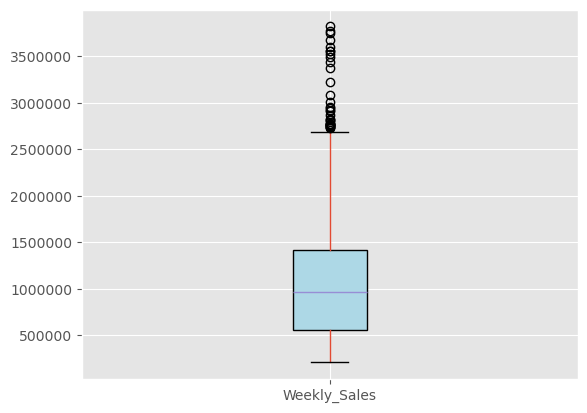

In [8]:
def sales_dis(df):
    #Check the distribution of the weekly sales
    plt.ticklabel_format(style='plain', axis='y')
    df[['Weekly_Sales']].boxplot(patch_artist= True, 
                                 boxprops=dict(facecolor='lightblue', 
                                               color='black'))
    return plt.show ()


# --- Run Function ---    
sales_dis(df)

#### --- 3a. Quarterly Pattern ---
Which quarters of the year exhibit the highest average weekly sales, and are these seasonal patterns consistent across years?


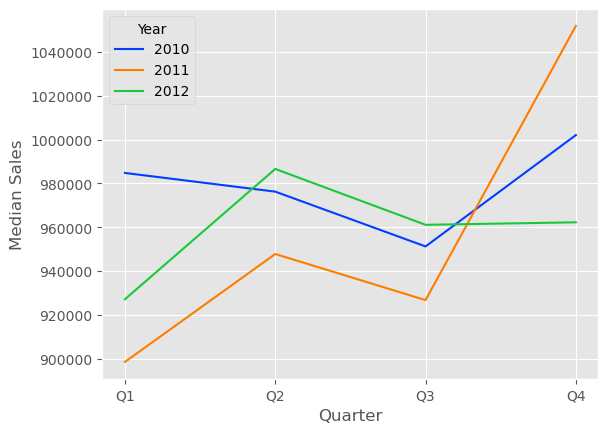

(            Q1        Q2        Q3         Q4
 Year                                         
 2010 984778.65 976242.09 951208.65 1002077.25
 2011 898449.73 947753.32 926695.10 1051944.79
 2012 927084.65 986612.02 961084.08  962230.85,
 <Figure size 640x480 with 1 Axes>)

In [9]:
def quarterly_sales_pattern(df):
    #How do sales move across quarters?
    quarter_sales = df.groupby(['Year', 'Quarter'])['Weekly_Sales'].agg(['median']).unstack()
    quarter_sales.columns = ['Q1', 'Q2', 'Q3', 'Q4'] 

    
    #Draw visualisable plots
    melted = quarter_sales.reset_index().melt (id_vars = 'Year', 
                                 value_vars = quarter_sales.columns,
                                  value_name = 'Median Sales',
                                  var_name = 'Quarter'
                                 )
    
    fig, ax = plt.subplots()
    sns.lineplot (x = 'Quarter', 
              y = 'Median Sales', 
              data = melted,
             hue = 'Year', palette='bright')
    plt.ticklabel_format(style='plain', axis='y')
    plt.show()
    return quarter_sales, fig 

# --- Run Function --- 
quarterly_sales_pattern(df)


#### --- 3b. Markdown Impact ---
Does sales performance differ between markdown and non-markdown periods and by how much percent, 
and does this difference vary across stores and store sizes?

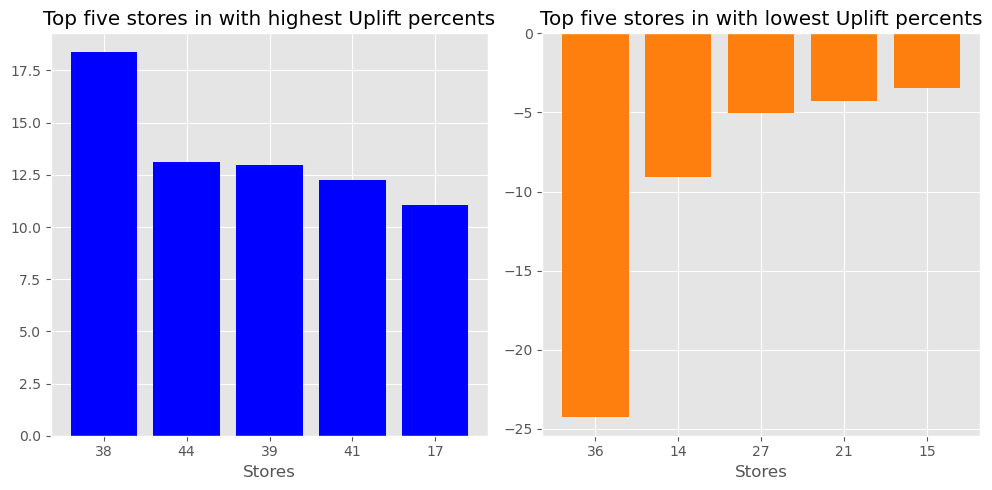

(       No_Markdown_Median  Markdown_Median  No_Markdown_Count  Markdown_Count  \
 Store                                                                           
 38              357221.63        422810.12                 92              51   
 44              288283.81        326053.28                 92              51   
 39             1348220.80       1522978.54                 92              51   
 41             1186001.12       1331514.44                 92              51   
 17              844847.78        938303.28                 92              51   
 7               539220.09        593875.46                 92              51   
 3               380046.88        418112.76                 92              51   
 5               302354.50        330063.06                 92              51   
 4              1993427.58       2174514.13                 92              51   
 9               519045.10        562173.12                 92              51   
 42             

In [24]:
def markdown_uplift_analysis_store (df):
    #Group store based on each store and markdown as initial discovery show that smaller store have less markdown so 
    #group by stores help to avoid skew the data
    
    store_markdown = df.groupby(['Store', 'Has_Markdown'])['Weekly_Sales'].agg(['median','count']).unstack()
    store_markdown.columns = ['No_Markdown_Median','Markdown_Median',
                           'No_Markdown_Count','Markdown_Count']
    
    store_markdown ['Uplift %'] = (store_markdown ['Markdown_Median'] - store_markdown ['No_Markdown_Median'])/ store_markdown ['No_Markdown_Median']*100


    #Draw visualisable plots
    #As there are 45 stores hence the plot will show the top 5 and worst 5 stores 
    plot_data = store_markdown.reset_index() 
    top5 = plot_data.sort_values ('Uplift %', ascending = False).head (5)
    tail5 = plot_data.sort_values ('Uplift %', ascending = True).head (5)

    fig, axes = plt.subplots(1, 2, figsize=(10, 5))

    x1 = range(len(top5))
    x2 = range(len(tail5))

    axes[0].bar(x1, top5['Uplift %'], color = 'blue')
    axes[0].set_xticks(x1)
    axes[0].set_xticklabels(top5['Store'])
    axes[0].set_xlabel ('Stores')
    axes[0].set_title('Top five stores in with highest Uplift percents')
    
    axes[1].bar(x2, tail5['Uplift %'], color = '#ff7f0e')
    axes[1].set_xticks(x2)
    axes[1].set_xticklabels(tail5['Store'])
    axes[1].set_xlabel ('Stores')
    axes[1].set_title('Top five stores in with lowest Uplift percents')

    plt.tight_layout()
    plt.show()
    return store_markdown.sort_values ('Uplift %', ascending = False), fig


# --- Run Function --- 
markdown_uplift_analysis_store (df)

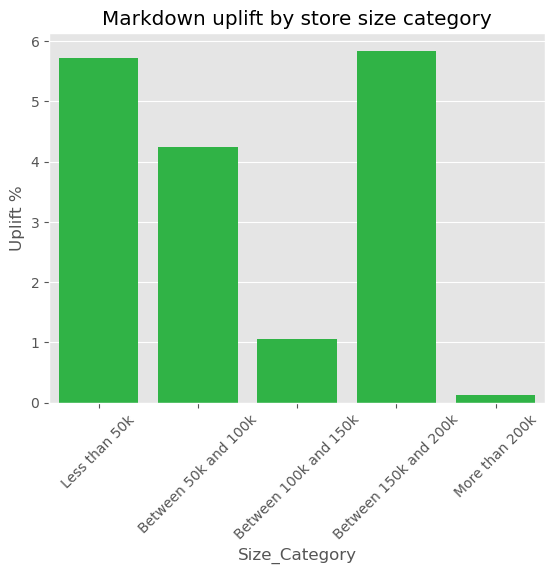

(                       No_Markdown_Median  Markdown_Median  No_Markdown_Count  \
 Size_Category                                                                   
 Between 150k and 200k          1024387.97       1084243.91                644   
 Less than 50k                   395231.45        417876.55                920   
 Between 50k and 100k            552095.01        575525.60                368   
 Between 100k and 150k           871303.71        880576.33               1012   
 More than 200k                 1588347.15       1590274.72               1196   
 
                        Markdown_Count  Uplift %  
 Size_Category                                    
 Between 150k and 200k             357      5.84  
 Less than 50k                     510      5.73  
 Between 50k and 100k              204      4.24  
 Between 100k and 150k             561      1.06  
 More than 200k                    663      0.12  ,
 <Figure size 640x480 with 1 Axes>)

In [30]:
def markdown_uplift_analysis_store_size (df):
    #As the size each store is unique to itself so I will divide into each category for this analysis question 
    size_buckets = [0, 50000, 100000,150000, 200000, np.inf]
    size_bucket_labels = ['Less than 50k',
                          'Between 50k and 100k',
                         'Between 100k and 150k',
                         'Between 150k and 200k',
                          'More than 200k']
    
    df['Size_Category'] = pd.cut (df['Size'], bins = size_buckets, labels = size_bucket_labels)
     
    size_markdown = df.groupby(['Size_Category', 'Has_Markdown'])['Weekly_Sales'].agg(['median','count']).unstack()
    
    size_markdown.columns = ['No_Markdown_Median','Markdown_Median',
                           'No_Markdown_Count','Markdown_Count']
    
    size_markdown['Uplift %'] = (size_markdown['Markdown_Median'] - size_markdown['No_Markdown_Median'])/ size_markdown['No_Markdown_Median']*100

    
    #Draw visualisable plots
    plot_data = size_markdown.reset_index()

    #Create figure explicitly
    fig, ax = plt.subplots()
    sns.barplot (x = 'Size_Category', y = 'Uplift %', data = plot_data, color = '#1AC938')
    plt.xticks (plot_data['Size_Category'],rotation = 45)
    plt.title ('Markdown uplift by store size category')
    plt.show()
    
    return size_markdown.sort_values ('Uplift %', ascending = False), fig


# --- Run Function --- 
markdown_uplift_analysis_store_size (df)

#### --- 3c. Markdown Combinations ---
Does combining multiple promotions lead to greater sales impact compared to single-promotion periods?
and if so which markdowns benefit from stacking?

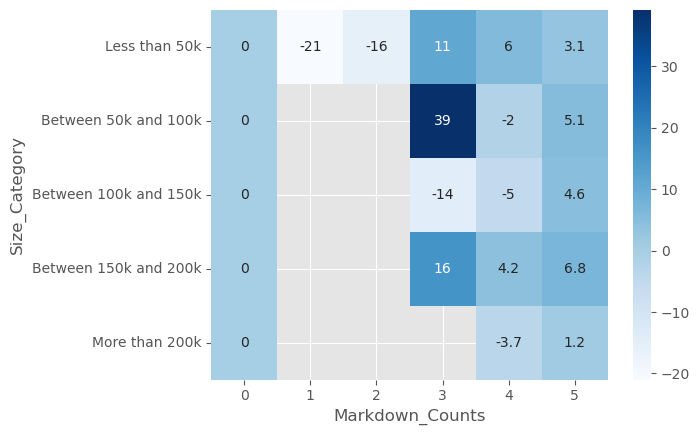

(                                       Weekly_Sales  Store_Week_Obs  Uplift %
 Size_Category         Markdown_Counts                                        
 Less than 50k         0                   395231.45             920      0.00
                       1                   312298.37               5    -20.98
                       2                   333146.88              81    -15.71
                       3                   439424.50             171     11.18
                       4                   418925.47             175      5.99
                       5                   407626.54              78      3.14
 Between 50k and 100k  0                   552095.01             368      0.00
                       1                         NaN               0       NaN
                       2                         NaN               0       NaN
                       3                   768304.94               2     39.16
                       4                   541120.20

In [12]:
def markdown_count_storesize_impact (df):
    #See how different number of markdown at the same time have on each store size
    melted = df.melt (id_vars = ['Store','Size_Category', 'Date', 'Weekly_Sales'], 
                         value_vars = Markdown_Cols,
                var_name = 'Markdown_Type', value_name = 'Values')
    
    grouped_melted = melted.groupby (['Store','Size_Category', 'Date', 'Weekly_Sales'],   observed=True  )\
    .agg(Markdown_Counts = ('Values', lambda x: (x.notna()).sum()))\
    .reset_index()
    
    final = grouped_melted.groupby (['Size_Category', 'Markdown_Counts']).agg(Weekly_Sales = ('Weekly_Sales', 'median'),
                                                                        Store_Week_Obs = ('Date', 'count')).reset_index()

    
    #Define the uplift function for each store size based on their according baseline
    def uplift (row): 
        baseline = final [ (final['Size_Category'] == row['Size_Category']) & 
                           (final['Markdown_Counts'] == 0) ]['Weekly_Sales'].values[0] 
        return (row['Weekly_Sales'] - baseline)/baseline*100
    
    final['Uplift %'] = final.apply(uplift, axis = 1)

    #Draw the visual plot 
    plot_data = final[['Size_Category',
                       'Markdown_Counts',
                      'Uplift %']].pivot (index = 'Size_Category',
                                         columns = 'Markdown_Counts',
                                         values = 'Uplift %')

    fig, ax = plt.subplots()
    sns.heatmap (plot_data, annot = True, cmap = 'Blues')
    plt.show()
    return final.set_index (['Size_Category','Markdown_Counts']), fig


# --- Run Function --- 
markdown_count_storesize_impact (df)

In [13]:
def each_store_md_combo (df, input_size_category):
    #Define which combo of markdown work best for each store size with obs counts
    melted = df.melt (id_vars = ['Store','Size_Category', 'Date', 'Weekly_Sales'], 
                      value_vars = Markdown_Cols,
                      var_name = 'Markdown_Type', 
                      value_name = 'Values')
    
    store_group = melted[(melted['Values'].notna()) & (melted['Size_Category'] == input_size_category.strip())]
    store_group = store_group.groupby(['Date','Weekly_Sales'])['Markdown_Type']\
                             .apply(lambda x: ' + '.join (sorted(x)))\
                             .reset_index()
                                                         
    final = store_group.groupby ('Markdown_Type').agg(Count_Obs = ('Date','count'),
                                             Median_Sales = ('Weekly_Sales','median'))
    
    return final.sort_values ('Median_Sales', ascending = False), None


# --- Run Function --- 
each_store_md_combo (df, 'Less than 50k ')

(                                                    Count_Obs  Median_Sales
 Markdown_Type                                                              
 MarkDown1 + MarkDown3 + MarkDown5                         130     507289.32
 MarkDown3 + MarkDown5                                       8     484355.36
 MarkDown1 + MarkDown2 + MarkDown3 + MarkDown5              80     442892.27
 MarkDown1 + MarkDown3 + MarkDown4 + MarkDown5              66     424709.02
 MarkDown1 + MarkDown2 + MarkDown3 + MarkDown4 +...         78     407626.54
 MarkDown2 + MarkDown3 + MarkDown5                           2     380863.53
 MarkDown1 + MarkDown2 + MarkDown4 + MarkDown5              29     351832.03
 MarkDown1 + MarkDown5                                      73     330518.34
 MarkDown1 + MarkDown2 + MarkDown5                          25     328498.92
 MarkDown1 + MarkDown4 + MarkDown5                          14     325440.68
 MarkDown5                                                   5     312298.37

#### --- 3d. Holiday Impact ---
Do larger stores consistently generate higher weekly sales than smaller stores across both holiday and non-holiday periods? 

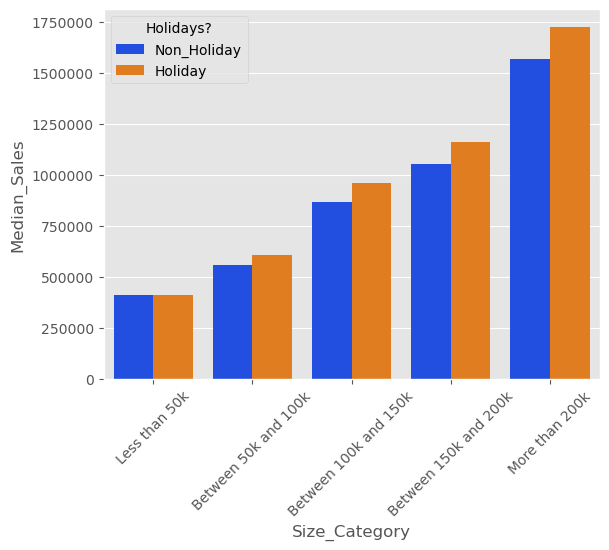

(                      Non_Holiday   Holiday  Non_Holiday      Holiday Uplift %
                         Count_Obs Count_Obs Median_Sales Median_Sales         
 Size_Category                                                                 
 Less than 50k                1330       100    408434.12    408560.61     0.03
 Between 50k and 100k          532        40    555292.28    605505.89     9.04
 Between 100k and 150k        1463       110    866401.45    958416.01    10.62
 Between 150k and 200k         931        70   1049625.90   1158073.10    10.33
 More than 200k               1729       130   1567340.07   1724790.78    10.05,
 <Figure size 640x480 with 1 Axes>)

In [14]:
def holiday_impact (df): 
    test = df.groupby(['Size_Category', 'Is_Holiday']).agg(Count_Obs = ('Date', 'count'),
                                                   Median_Sales = ('Weekly_Sales', 'median'))\
    .unstack().swaplevel (0,1, axis = 1)
     
    test.columns = pd.MultiIndex.from_tuples([('Non_Holiday','Count_Obs'),
                ( 'Holiday','Count_Obs'),
                ('Non_Holiday', 'Median_Sales'),
                ( 'Holiday', 'Median_Sales')])
    test[('Uplift %')] =  (test[('Holiday', 'Median_Sales')] - test[('Non_Holiday', 'Median_Sales')])\
    / test[('Non_Holiday', 'Median_Sales')] *100
    
    
    # Draw visualisable plots
    plot = test.iloc[:, [2,3]].reset_index() 
    plot.columns = plot.columns.droplevel(1)
    plot = plot.melt (id_vars = 'Size_Category',
                     value_name = 'Median_Sales',
                     var_name = 'Holidays?')

    fig, ax = plt.subplots()
    sns.barplot (x = 'Size_Category',
                y = 'Median_Sales',
                data = plot,
                hue = 'Holidays?',
                palette = 'bright')
    
    plt.xticks(rotation = 45)
    plt.show()
    return test, fig

# --- Run Function --- 
holiday_impact (df)

#### --- 3e. Combined Effect ---
Do holidays drive higher weekly sales, 
and do markdown promotions amplify that effect and by how much?

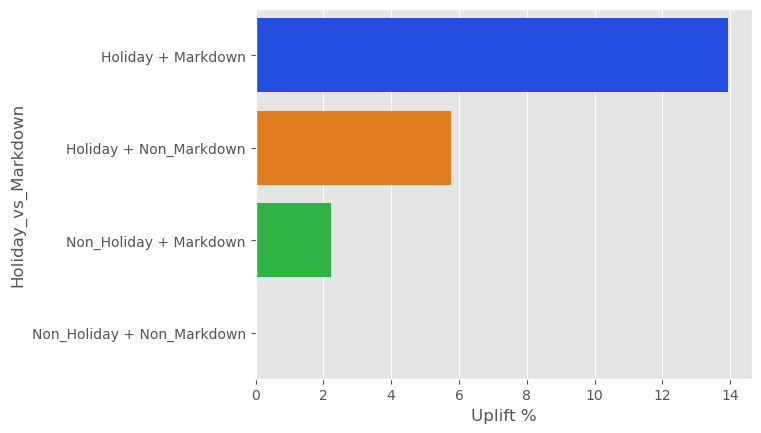

(          Holiday_vs_Markdown                 Interpretation  Median Sales  \
 3  Non_Holiday + Non_Markdown  Peak demand (stacked effects)     950255.01   
 2      Non_Holiday + Markdown           Holiday Demand spike     971386.65   
 1      Holiday + Non_Markdown          Markdown effects only    1004941.65   
 0          Holiday + Markdown                Baseline Demand    1082697.64   
 
    Week Counts  Uplift %  
 3         3870      0.00  
 2         2115      2.22  
 1          270      5.75  
 0          180     13.94  ,
 <Figure size 640x480 with 1 Axes>)

In [15]:
def holiday_vs_md_amplify(df): 
    #Check whether holiday and md amplify impacts of one another and which have more impacts on sales individually
    df['Holiday_vs_Markdown'] = df['Is_Holiday'].map ({True : 'Holiday', False : 'Non_Holiday'}) \
    +' + '+ df['Has_Markdown'].map ({True : 'Markdown', False : 'Non_Markdown'}) 
    
    combo_effect = df.groupby(['Holiday_vs_Markdown'])['Weekly_Sales'].agg(['median','count']).reset_index()
    
    combo_effect.insert (1, 'Interpretation', 
                        pd.Series (['Baseline Demand', 
                                    'Markdown effects only',
                                    'Holiday Demand spike', 
                                    'Peak demand (stacked effects)']))
                                             
     
    baseline = combo_effect[combo_effect['Holiday_vs_Markdown'] == 'Non_Holiday + Non_Markdown']['median'].values[0]
     
    combo_effect['Uplift %'] = (combo_effect['median'] -  baseline)/baseline *100
    combo_effect = combo_effect.rename(columns = {'median': 'Median Sales', 'count':'Week Counts'})

    fig, ax = plt.subplots()
    sns.barplot (x = 'Uplift %', y = 'Holiday_vs_Markdown', data = combo_effect, palette = 'bright')
    plt.show()
    return combo_effect.sort_values(by = 'Uplift %'), fig


# --- Run Function --- 
holiday_vs_md_amplify(df)

## 4. LOAD
Load the result files to local device in csv


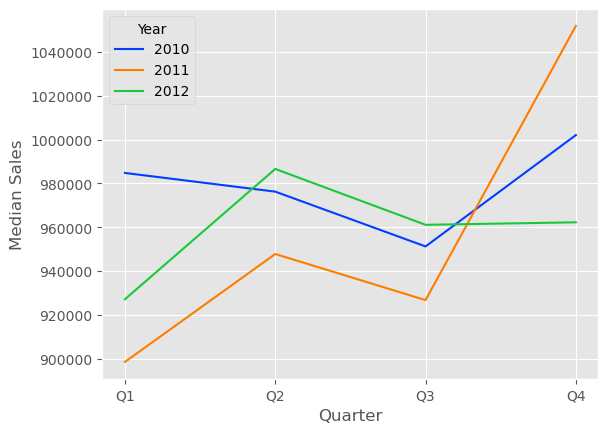

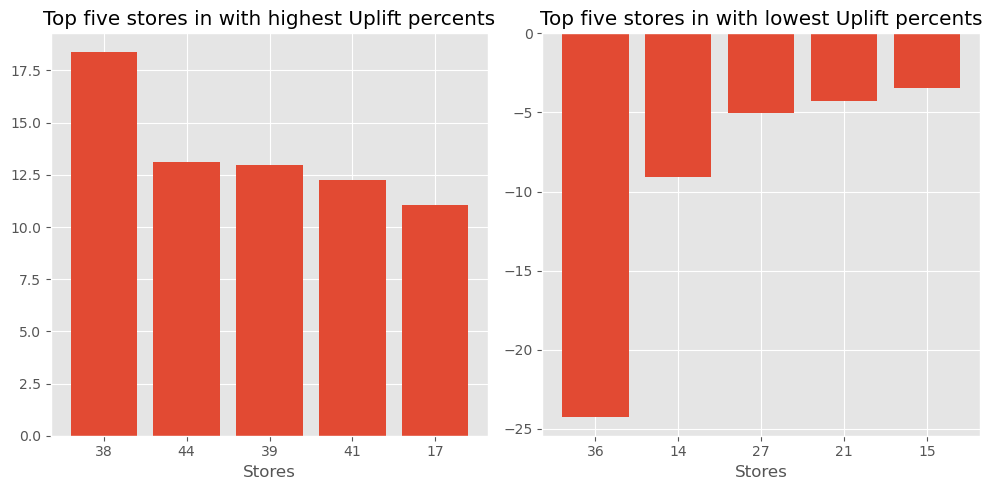

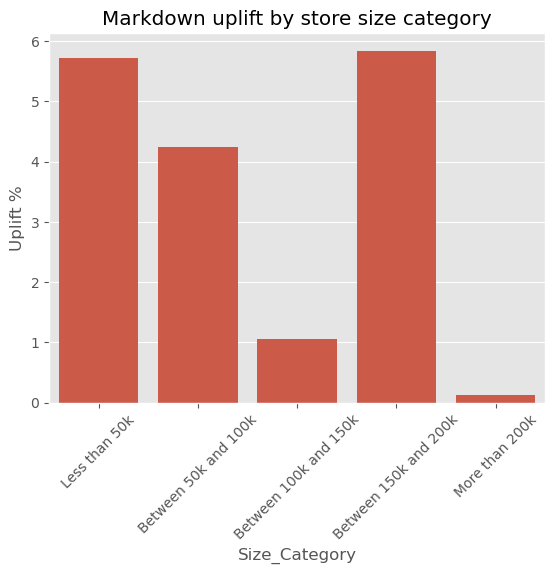

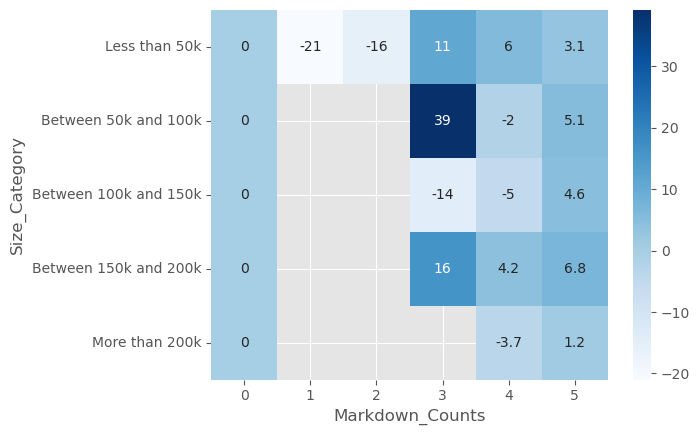

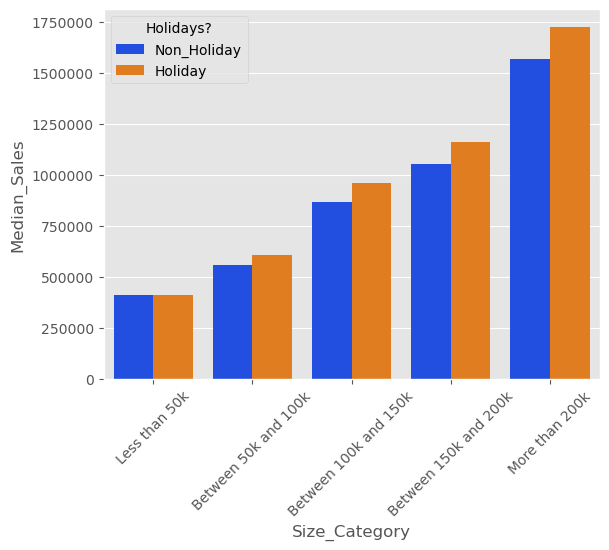

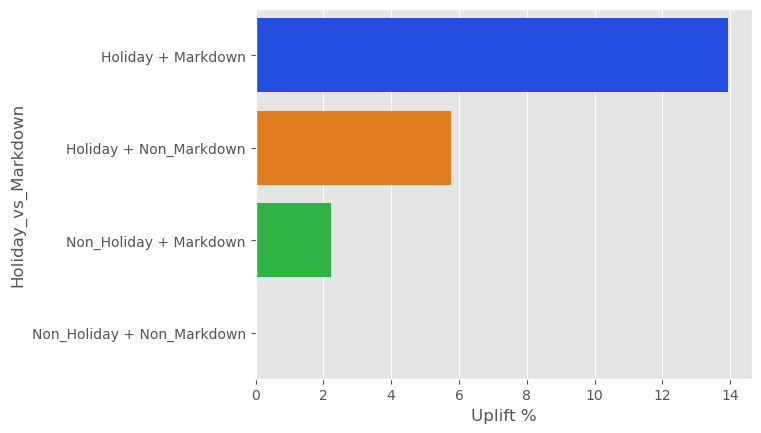

'Table and chart for holiday_vs_md_amplify saved to: /Users/sarahnguyen313/Documents/Walmart Project/holiday_markdown_combined_impact.csv'

In [18]:
def load_merged_data (df, output_path = output_path):
    # Save CSV file for merged df
    merged_data_path = os.path.join(output_path, "merged_data.csv")
    df.to_csv(merged_data_path, index=True)
    
    return f"Merged cleaned data has been saved to: {merged_data_path}"


def load_results (df, analysis_func, file_name, output_path = output_path):
    '''Acts as a generalised loader that takes a dataframe and any analysis function, run it and save the result as CSVs 
    and corresponding charts as PNG'''
    result_df, fig = analysis_func(df)

    # Create output folder if it doesn't exist
    os.makedirs(output_path, exist_ok=True)
    
    # Save CSV file for the analytical df and merged df
    file_path = os.path.join(output_path, f"{file_name}.csv")
    result_df.to_csv(file_path, index=True)
    
    if fig is not None:
        returned_output = "Table and chart"
        
        # Save the chart as PNG
        image_path = os.path.join(output_path, f"{file_name}.png")

        # dpi and bbox_inches are used to ensure high-res, perfectly cropped image saved
        fig.savefig(image_path, dpi=300, bbox_inches='tight')
        
        #Help to free memory
        plt.close(fig)   

    else:
        returned_output = "Table only (no chart)"
 

    return f"{returned_output} for {analysis_func.__name__} saved to: {file_path}"

# --- Run Loader for each question ---
load_results(df, quarterly_sales_pattern, 
             "quarterly_pattern")

load_results(df, markdown_uplift_analysis_store,  
             "markdown_uplift_per_store")

load_results(df, markdown_uplift_analysis_store_size,  
             "markdown_uplift_per_store_size")

load_results(df, markdown_count_storesize_impact, 
             "markdown_count_impact_on_storesize")

load_results(df, lambda f: each_store_md_combo(f, "Less than 50k"), 
             "md_combo_popularity_across_storesize")

load_results(df, holiday_impact, 
             "holiday_impact")

load_results(df, holiday_vs_md_amplify, 
             "holiday_markdown_combined_impact")



## 5. SUMMARY FINDINGS
### **Key Findings:**
 
#### Data Cleaning & Preprocessing
- Markdown columns expected to hold positive values contained some negative entries; these were minimal in count and hence converted to zero
- Merged the Stores, Features, and Sales tables into a single dataset; cropped the time range to match the Sales table (the primary metric), as Features spanned a longer period
- Excluded unemployment rate and happiness index from core analysis, with only ~3 years of data, their impact on sales would not be statistically meaningful to generalise
- Engineered additional columns: holiday flag, markdown flag, and markdown total values 
- Sales distribution showed significant outliers, so median sales was used as the primary measure throughout the project to avoid skew
- As the dataset in this project are limited to three years and one of the main metrics used are the markdown are often depends on the store size it is used so the result may not be exshautive and might be skewed so for most of the questions, I included the count of observations (store + markdown + week) so that factors can be accessed simultaneously 

#### Markdown Impact on Sales
- Markdown did not consistently produce positive sales uplift compared to no-markdown periods across all stores (observation counts were sufficiently large, 50+ per group, to meet the Central Limit Theorem and reduce extreme skew)
- No clear relationship found between store size and markdown-driven sales uplift, the largest store showed the lowest uplift, while the smallest showed the second highest; the remaining sizes followed no discernible pattern

#### Holiday Impact on Sales
- Holidays showed a positive impact on sales, and this effect was stronger than markdown's impact when each factor was assessed independently
- Markdown did amplify holiday-period sales, but holidays remained the dominant driver

#### Quarterly Sales Patterns
- Q1 and Q2 results varied across stores with no consistent winner between the two
The pattern in which Q3 consistently dipped from Q2 across all stores was seen in all years recorded
- Q4 saw a strong rebound across all stores, likely driven by the high concentration of public holidays in that period

#### Store Size & Sales
- Larger stores generally recorded higher absolute sales than smaller stores
Holiday uplift was also greater for larger stores, though the difference was not dramatic, the most notable gap between non-holiday and holiday was among the smallest store  

#### Markdown Combination Analysis
- Bundling more markdown types did not guarantee higher sales regardless of store size
Larger stores in general received more markdown combinations (more types applied simultaneously)
- Across store sizes, stores with the full combination of all 5 markdowns tended to perform best overall
However, a 4-markdown combo did not consistently outperform a 3-markdown combo, which was an unexpected finding
- The smallest store bucked the general trend, its highest sales were recorded under 2- or 3-markdown combinations; investigation revealed the MD3 + MD5 combo produced notably strong results, appearing in the two second-highest sales spots for that size tier
- Larger stores rarely had 2- or 3-markdown combinations, making direct comparison unreliable for those tiers
- MD5 alone ranked last in sales performance, suggesting it works best when paired with other markdown types, particularly MD3



 